### Imports

In [ ]:
import os
import torch
import librosa
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from torch.utils.data import Dataset, DataLoader, random_split

In [93]:
device = torch.device("cpu")
print("Using device:", device)

Using device: cpu


### CONFIG

In [ ]:
DATA_PATH = "D:/ML_Project/Multimodal Emotion Detection System using Computer Vision and NLP/data/audio"  

emotion_map = {
    "01": 0, "02": 1, "03": 2,
    "04": 3, "05": 4, "06": 5, "07": 6
}

emotion_labels = ['Neutral','Calm','Happy','Sad','Angry','Fear','Disgust']


### Load data

In [ ]:
def load_ravdess(data_path):
    file_paths, labels = [], []

    for actor in os.listdir(data_path):
        actor_path = os.path.join(data_path, actor)

        if not os.path.isdir(actor_path):
            continue

        for file in os.listdir(actor_path):
            if file.endswith(".wav"):
                parts = file.split("-")

                if len(parts) < 3:
                    continue

                emotion = parts[2]

                if emotion in emotion_map:
                    file_paths.append(os.path.join(actor_path, file))
                    labels.append(emotion_map[emotion])

    return file_paths, labels

### FEATURE EXTRACTION

In [ ]:
def extract_features(file, max_len=128):
    audio, sr = librosa.load(file, sr=22050)

    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
    mel = librosa.power_to_db(mel)

    mel = (mel - np.mean(mel)) / (np.std(mel) + 1e-6)

    if mel.shape[1] < max_len:
        mel = np.pad(mel, ((0,0),(0,max_len - mel.shape[1])))
    else:
        mel = mel[:, :max_len]
    return mel

### DATASET

In [ ]:
class VoiceDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        x = extract_features(self.files[idx])
        x = torch.tensor(x).unsqueeze(0).float()
        y = torch.tensor(self.labels[idx])
        return x, y

### MODEL

In [ ]:

class EmotionCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16*16,256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256,7)
        )

    def forward(self,x):
        return self.fc(self.conv(x))

###  PREPARE DATA

In [ ]:

torch.manual_seed(42)

files, labels = load_ravdess(DATA_PATH)
dataset = VoiceDataset(files, labels)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

print("Train:", len(train_data), "Val:", len(val_data), "Test:", len(test_data))

Train: 873 Val: 187 Test: 188


### TRAINING

In [ ]:
EPOCHS = 40
BATCH_SIZE = 32
model = EmotionCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

train_losses = []
val_accuracies = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_losses.append(total_loss)

### VALIDATION

In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        _, pred = torch.max(out, 1)

        correct += (pred == y).sum().item()
        total += y.size(0)

val_acc = 100 * correct / total
val_accuracies.append(val_acc)

print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}, Val Acc: {val_acc:.2f}%")


Epoch 40, Loss: 3.3022, Val Acc: 64.71%


 ### SAVE MODEL

In [ ]:
torch.save(model.state_dict(), "../models/voice_emotion_model.pth")
print("Model saved!")


Model saved!


###  TEST EVALUATION

In [ ]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = model(x)
        _, pred = torch.max(out, 1)

        y_true.extend(y.numpy())
        y_pred.extend(pred.cpu().numpy())

accuracy = np.mean(np.array(y_true) == np.array(y_pred))
print("Test Accuracy:", accuracy * 100)

Test Accuracy: 72.3404255319149


### CONFUSION MATRIX

<Figure size 800x600 with 0 Axes>

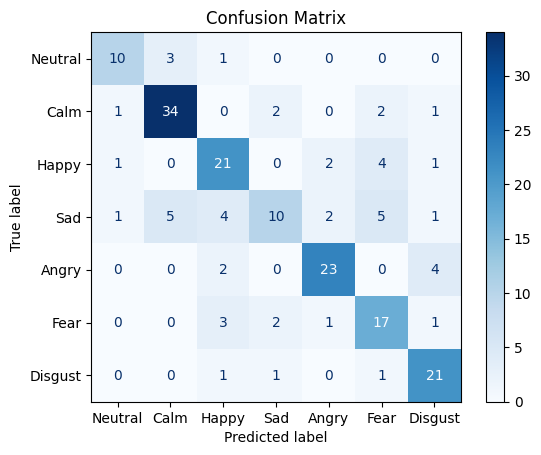

In [ ]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=emotion_labels)

plt.figure(figsize=(8,6))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

### CLASSIFICATION REPORT

In [ ]:
print(classification_report(y_true, y_pred, target_names=emotion_labels))

              precision    recall  f1-score   support

     Neutral       0.77      0.71      0.74        14
        Calm       0.81      0.85      0.83        40
       Happy       0.66      0.72      0.69        29
         Sad       0.67      0.36      0.47        28
       Angry       0.82      0.79      0.81        29
        Fear       0.59      0.71      0.64        24
     Disgust       0.72      0.88      0.79        24

    accuracy                           0.72       188
   macro avg       0.72      0.72      0.71       188
weighted avg       0.72      0.72      0.71       188



### TRAINING GRAPH

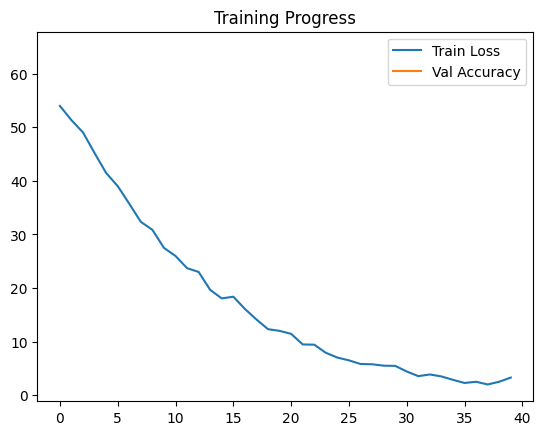

In [ ]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_accuracies, label="Val Accuracy")
plt.legend()
plt.title("Training Progress")
plt.show()